# **DNN Object Detection with YOLOX**

## **Objectives:**
1. Load a pretrained, 80-class object detector through `cv2.dnn` + ONNX — no training, just inference
2. Understand the letterbox → forward pass → grid/stride decode → NMS pipeline a modern detector actually runs
3. Compare it against notebook 17's background-subtraction vehicle detector on the exact same footage

> **Assets.** `assets/models/object_detection_yolox_2022nov_int8.onnx` is YOLOX-s from OpenCV's own model zoo ([opencv/opencv_zoo](https://github.com/opencv/opencv_zoo/tree/main/models/object_detection_yolox), Apache 2.0). This is the **int8-quantized** export (~9MB) rather than the full-precision one (~36MB) — a deliberate size/accuracy tradeoff to keep this repo's assets lean, the same reasoning behind picking YuNet's small model in notebook 30. YOLOX was picked over the more commonly-known Ultralytics YOLO releases specifically because it's Apache-2.0 — Ultralytics' own YOLO packages are AGPL-3.0, a copyleft license that doesn't fit a repo meant to be freely reused. The letterbox/grid-decode logic below follows OpenCV zoo's own reference `demo.py` for this model.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [2]:
# The 80 COCO classes this model was trained on, in the model's own class-index order
COCO_CLASSES = (
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
    'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush',
)

## **Why letterbox, not a plain resize**

YOLOX expects a fixed 640×640 input, but `messi5.jpg` and a highway frame are neither square nor that size. A naive `cv2.resize` to 640×640 would stretch every object's aspect ratio — a circular ball would come out oval, distorting exactly the shape cues the network learned to recognize. **Letterboxing** instead scales the image down uniformly (preserving aspect ratio) and pads the leftover space with a neutral gray (114,114,114) — the same trick notebook 6 covered for interpolation-safe resizing, applied here because a detector's accuracy depends on it directly.

In [3]:
def letterbox(img, target_size=(640, 640)):
    padded = np.full((target_size[0], target_size[1], 3), 114.0, dtype=np.float32)
    ratio = min(target_size[0] / img.shape[0], target_size[1] / img.shape[1])
    new_w, new_h = int(img.shape[1] * ratio), int(img.shape[0] * ratio)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR).astype(np.float32)
    padded[:new_h, :new_w] = resized
    return padded, ratio

## **Grid/stride decoding — what "anchor-free" actually means**

Older YOLO versions predicted offsets relative to a fixed set of pre-defined *anchor box* shapes ("is this closer to my tall-box template or my wide-box template?"). YOLOX is **anchor-free**: it divides the image into a grid at three scales (stride 8, 16, 32 — fine, medium, coarse) and predicts, for every grid cell, a raw (x, y) offset *from that cell's own position* and a (w, h) in log-space relative to the stride. `generate_anchors` below isn't loading pretrained anchor boxes — it's just building the (cell position, stride) lookup table the raw network output needs to be decoded against. This is a fundamentally simpler design than anchor boxes (fewer hyperparameters to tune), one of YOLOX's actual selling points over earlier YOLO generations.

In [4]:
def generate_anchors(input_size=(640, 640), strides=(8, 16, 32)):
    grids, expanded_strides = [], []
    for stride in strides:
        h, w = input_size[0] // stride, input_size[1] // stride
        xv, yv = np.meshgrid(np.arange(h), np.arange(w))
        grid = np.stack((xv, yv), 2).reshape(1, -1, 2)
        grids.append(grid)
        expanded_strides.append(np.full((*grid.shape[:2], 1), stride))
    return np.concatenate(grids, 1)[0], np.concatenate(expanded_strides, 1)[0]

GRIDS, STRIDES = generate_anchors()
net = cv2.dnn.readNet('assets/models/object_detection_yolox_2022nov_int8.onnx')

## **The full pipeline**

`dets[:, :5]` is (x, y, w, h, objectness) per grid cell; `dets[:, 5:]` is 80 per-class scores. `objectness * class_score` gives the final confidence per class — a detection only counts if the cell is confident *both* that something is there *and* what it is. `cv2.dnn.NMSBoxesBatched` runs non-max suppression separately per class, so an overlapping "car" and "truck" box (genuine classification ambiguity, not a bug) can both survive — worth watching for below.

In [5]:
def detect(img, conf_threshold=0.5, nms_threshold=0.5):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    letterboxed, scale = letterbox(rgb)
    blob = np.transpose(letterboxed, (2, 0, 1))[np.newaxis, :, :, :]
    net.setInput(blob)
    dets = net.forward(net.getUnconnectedOutLayersNames())[0][0]

    dets[:, :2] = (dets[:, :2] + GRIDS) * STRIDES
    dets[:, 2:4] = np.exp(dets[:, 2:4]) * STRIDES

    boxes = np.empty_like(dets[:, :4])
    boxes[:, 0] = dets[:, 0] - dets[:, 2] / 2
    boxes[:, 1] = dets[:, 1] - dets[:, 3] / 2
    boxes[:, 2:4] = dets[:, 2:4]

    scores = dets[:, 4:5] * dets[:, 5:]
    class_ids = np.argmax(scores, axis=1)
    confidences = np.amax(scores, axis=1)

    keep = cv2.dnn.NMSBoxesBatched(
        boxes.tolist(), confidences.tolist(), class_ids.tolist(),
        conf_threshold, nms_threshold,
    )
    results = []
    for i in keep:
        x, y, w, h = (int(v) for v in boxes[i] / scale)
        results.append((COCO_CLASSES[class_ids[i]], float(confidences[i]), (x, y, w, h)))
    return results


def draw_detections(img, detections):
    vis = img.copy()
    for label, conf, (x, y, w, h) in detections:
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(vis, f'{label} {conf:.2f}', (x, max(0, y - 6)),
                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
    return vis

sports ball: 0.92 at (336, 287, 50, 49)
person: 0.92 at (64, 60, 384, 271)


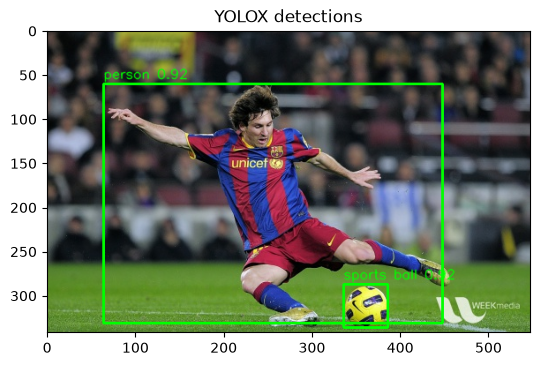

In [6]:
image = cv2.imread('assets/images/messi5.jpg')
detections = detect(image)
for label, conf, box in detections:
    print(f'{label}: {conf:.2f} at {box}')
imshow('YOLOX detections', draw_detections(image, detections))

## **Against notebook 17: detection vs. background subtraction**

Notebook 17's background-subtraction vehicle detector needs *motion across several frames* to build up a model of "what's usually here" before it can flag anything as foreground — pause the video on frame one and it finds nothing. YOLOX needs exactly one frame: it recognizes a car *by what a car looks like*, not by noticing it moved. That's the real, structural difference between a background model and a trained object detector — not just "one is older," they solve the detection problem in fundamentally different ways, and the video-vs-single-frame requirement is the direct consequence.

15 vehicles found in a single still frame (no motion/background model needed)


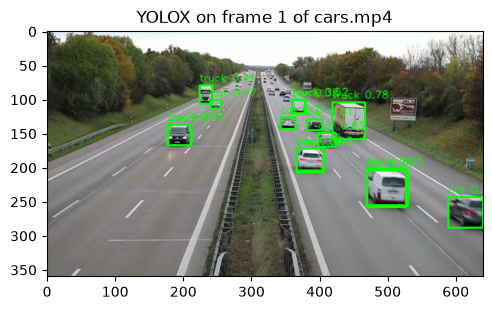

In [7]:
cap = cv2.VideoCapture('assets/videos/cars.mp4')
ok, frame = cap.read()
cap.release()
assert ok, 'could not read a frame from cars.mp4'

detections = detect(frame, conf_threshold=0.35)
print(f'{len(detections)} vehicles found in a single still frame '
      f'(no motion/background model needed)')
imshow('YOLOX on frame 1 of cars.mp4', draw_detections(frame, detections))

### If you want to push this further

- Run `detect()` on every Nth frame of `assets/videos/cars.mp4` and compare vehicle counts against notebook 17's background-subtraction contour count — they won't match exactly, and figuring out *why* (occlusion, the car/truck ambiguity above, confidence threshold) is the actual lesson.
- Swap in `object_detection_nanodet_2022nov.onnx` from the same opencv_zoo directory (also Apache 2.0) and compare speed vs. detection quality against YOLOX on the same frame.
- Lower `conf_threshold` to 0.1 and watch false positives flood in — a concrete, visual feel for why 0.5 isn't an arbitrary default.